# Исследование объявлений о продаже квартир

В распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Необходимо научиться определять рыночную стоимость объектов недвижимости. Для этого нужно провести исследовательский анализ данных и установить параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

**Цель исследования:**
1. Определить рыночную стоимость объектов недвижимости.
2. Построить автоматизированную систему, которая отследит аномалии и мошенническую деятельность.
3. Установить, какие факторы влияют на ценообразование квартир.

**Ход исследования:**
- Получить данные из файла real_estate_data.csv
- Выполнить обзор полученных данных
- При обнаружении ошибок в данных по возможности исправить их
- Расчёт и добавление новых параметров
- Выполнить исследовательский анализ данных
- Определить факторы, влияющие на стоимость квартиры

## Получение данных и общий обзор

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
    
display(data.head())

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

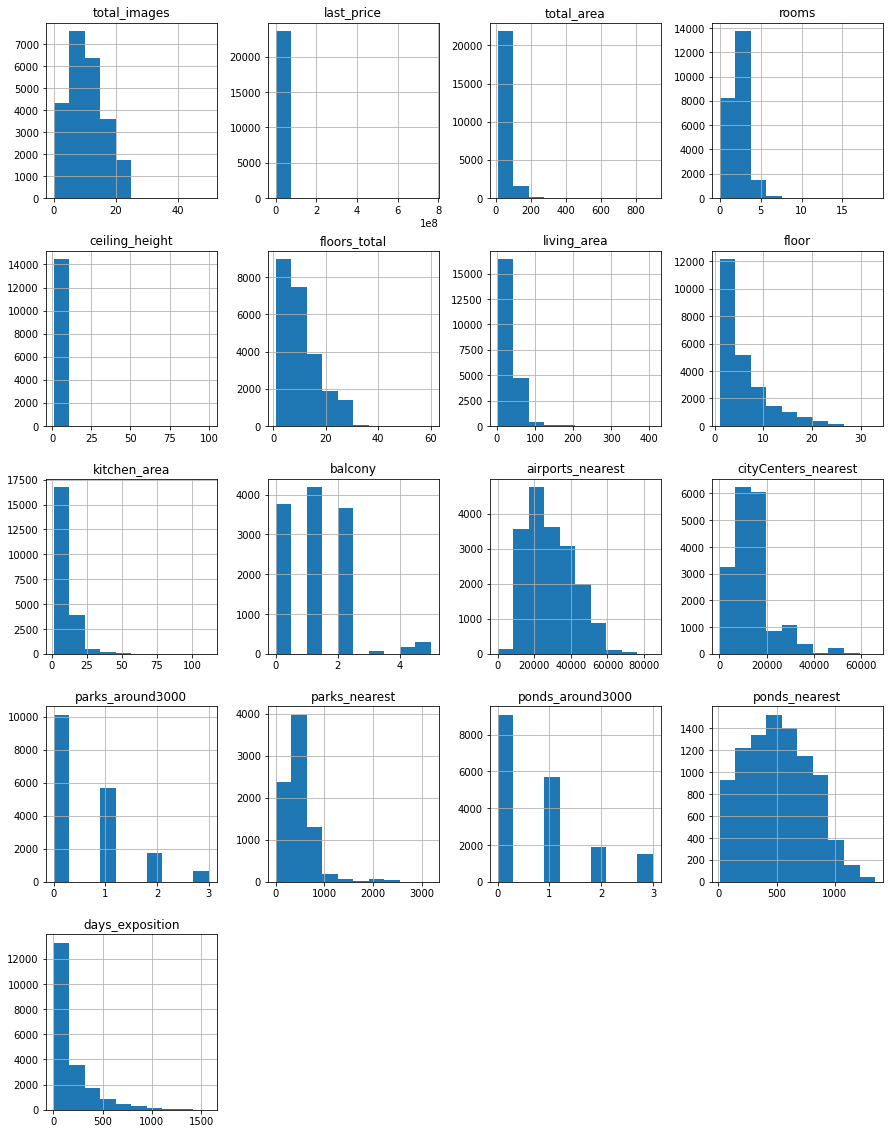

In [4]:
data.hist(figsize=(15, 20))
plt.show();

**Вывод:** Набор данных состоит из 23699 объектов. По гистограммам числовых параметров на первый взгляд брасаются в глаза сильные выбросы от более распространнённых значений у цены, общей площади и высоты потолков, а так же двойные пики у расстояния до центра и до парка.

## Предобработка данных

### Изучение пропущенных значений

In [5]:
data.duplicated().sum()

0

In [6]:
print(data.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


Строки с незаполненным параметром locality_name (название населённого пункта) можно удалить, т.к. неизвестно откуда данные пришли (возможно какой-то другой регион) и их достаточно мало (0.2% от общего числа данных), что не должно повлиять на анализ. Зато эти строки не будут мешать при анализе влияния населённого пункта на стоимость.

In [7]:
data = data.dropna(subset=['locality_name'])

In [8]:
print(data['is_apartment'].value_counts())

False    2710
True       50
Name: is_apartment, dtype: int64


Параметры<br>
*ceiling_height* — высота потолков (м)<br>
*floors_total* — всего этажей в доме<br>
*living_area* — жилая площадь в квадратных метрах (м²)<br>
*is_apartment* — апартаменты (булев тип)<br>
*kitchen_area* — площадь кухни в квадратных метрах (м²)<br>
*balcony* — число балконов<br>
скорее всего не были обязательными и далеко не всегда указывались клиентами.<br>
<br>
Для *is_apartment* отсутствующие значения можно заменить на False, предполагая, что отмечали как апартаменты именно те объекты, которые являлись апартаментами. Но выставленных в True значений очень мало (предположение может быть ошибочным) и данное преобразование может не понадобиться для анализа.
<br>
Для *balcony* отсутствующие значения можно заменить нулями
<br>
Для остальных пока останется значение NaN 

In [9]:
data['balcony'] = data['balcony'].fillna(0)

Параметры<br>
*airports_nearest* — расстояние до ближайшего аэропорта в метрах (м)<br>
*cityCenters_nearest* — расстояние до центра города (м)<br>
*parks_around3000* — число парков в радиусе 3 км<br>
*parks_nearest* — расстояние до ближайшего парка (м)<br>
*ponds_around3000* — число водоёмов в радиусе 3 км<br>
*ponds_nearest* — расстояние до ближайшего водоёма (м)<br>
заполнялись автоматически. Возможно из-за ошибок или нехватки данных в адресах геосервисы не смогли определить значения.<br>
Сочетание *parks_around3000* = 0 с *parks_nearest* = NaN и *ponds_around3000* = 0 с *ponds_nearest* = NaN вполне логично. Обратная ситуайия не наблюдается<br>
Пока оставим эти параметры как есть.

In [10]:
data.query('(not parks_nearest.isna() and parks_around3000.isna()) or (not ponds_nearest.isna() and ponds_around3000.isna())')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition


In [11]:
print(data['days_exposition'].describe())

count    20470.000000
mean       180.753200
std        219.777916
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64


Параметр days_exposition - сколько дней было размещено объявление (от публикации до снятия) - скорее всего осталось незаполненным для всё ещё открытых объявлений. При необходимости, преобразовав тип данных колонки first_day_exposition, параметр можно будет рассчитать как количество дней между first_day_exposition и датой предоставления данных (либо текущей)

In [12]:
print(data.isna().sum())

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9160
floors_total               85
living_area              1898
floor                       0
is_apartment            20890
studio                      0
open_plan                   0
kitchen_area             2269
balcony                     0
locality_name               0
airports_nearest         5534
cityCenters_nearest      5511
parks_around3000         5510
parks_nearest           15586
ponds_around3000         5510
ponds_nearest           14565
days_exposition          3180
dtype: int64


### Типы данных столбцов

Для удобства работы с датой преобразую first_day_exposition в datetime

In [13]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
print(type(data['first_day_exposition'][0]))
data.head()

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,NaN,...,25.0,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,NaN,...,41.0,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


Колонку balcony можно преобразование в int, т.к. теперь отсутствуют NaN

In [14]:
data['balcony'] = data['balcony'].astype('int')

In [15]:
print(data['balcony'].value_counts())

0    15238
1     4187
2     3658
5      304
4      182
3       81
Name: balcony, dtype: int64


In [16]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23650 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  float64       
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[ns]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        14490 non-null  float64       
 6   floors_total          23565 non-null  float64       
 7   living_area           21752 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   is_apartment          2760 non-null   object        
 10  studio                23650 non-null  bool          
 11  open_plan             23650 non-null  bool          
 12  kitchen_area          21381 non-null  float64       
 13  balcony         

### Устранение неявных дубликатов

In [17]:
print(data['locality_name'].unique())

['Санкт-Петербург' 'посёлок Шушары' 'городской посёлок Янино-1'
 'посёлок Парголово' 'посёлок Мурино' 'Ломоносов' 'Сертолово' 'Петергоф'
 'Пушкин' 'деревня Кудрово' 'Коммунар' 'Колпино'
 'поселок городского типа Красный Бор' 'Гатчина' 'поселок Мурино'
 'деревня Фёдоровское' 'Выборг' 'Кронштадт' 'Кировск'
 'деревня Новое Девяткино' 'посёлок Металлострой'
 'посёлок городского типа Лебяжье' 'посёлок городского типа Сиверский'
 'поселок Молодцово' 'поселок городского типа Кузьмоловский'
 'садовое товарищество Новая Ропша' 'Павловск' 'деревня Пикколово'
 'Всеволожск' 'Волхов' 'Кингисепп' 'Приозерск' 'Сестрорецк'
 'деревня Куттузи' 'посёлок Аннино' 'поселок городского типа Ефимовский'
 'посёлок Плодовое' 'деревня Заклинье' 'поселок Торковичи'
 'поселок Первомайское' 'Красное Село' 'посёлок Понтонный' 'Сясьстрой'
 'деревня Старая' 'деревня Лесколово' 'посёлок Новый Свет' 'Сланцы'
 'село Путилово' 'Ивангород' 'Мурино' 'Шлиссельбург' 'Никольское'
 'Зеленогорск' 'Сосновый Бор' 'поселок Новый Све

Добавление новой колонки *locality_name_corrected*, содержащей названия населённых пунктов без дубликатов:

In [18]:
data['locality_name_corrected'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace('Мурино', 'поселок Мурино', regex=True)
    .replace('деревня Кудрово', 'Кудрово', regex=True)
    .replace('городской поселок Рощино', 'поселок городского типа Рощино', regex=True)
    .replace('городской поселок Советский', 'поселок городского типа Советский', regex=True)
    .replace('городской поселок Большая Ижора', 'поселок городского типа Большая Ижора', regex=True)
    .replace('городской поселок Павлово', 'поселок городского типа Павлово', regex=True)
    .replace('городской поселок Лесогорский', 'поселок городского типа Лесогорский', regex=True)
    .replace('городской поселок Мга', 'поселок городского типа Мга', regex=True)
    .replace('поселок станции Вещево', 'поселок при железнодорожной станции Вещево', regex=True)
    .replace('городской поселок Назия', 'поселок городского типа Назия', regex=True)
    .replace('поселок станции Приветнинское', 'поселок при железнодорожной станции Приветнинское', regex=True)
) 
print(data['locality_name_corrected'].unique())

['Санкт-Петербург' 'поселок Шушары' 'городской поселок Янино-1'
 'поселок Парголово' 'поселок поселок Мурино' 'Ломоносов' 'Сертолово'
 'Петергоф' 'Пушкин' 'Кудрово' 'Коммунар' 'Колпино'
 'поселок городского типа Красный Бор' 'Гатчина' 'деревня Федоровское'
 'Выборг' 'Кронштадт' 'Кировск' 'деревня Новое Девяткино'
 'поселок Металлострой' 'поселок городского типа Лебяжье'
 'поселок городского типа Сиверский' 'поселок Молодцово'
 'поселок городского типа Кузьмоловский'
 'садовое товарищество Новая Ропша' 'Павловск' 'деревня Пикколово'
 'Всеволожск' 'Волхов' 'Кингисепп' 'Приозерск' 'Сестрорецк'
 'деревня Куттузи' 'поселок Аннино' 'поселок городского типа Ефимовский'
 'поселок Плодовое' 'деревня Заклинье' 'поселок Торковичи'
 'поселок Первомайское' 'Красное Село' 'поселок Понтонный' 'Сясьстрой'
 'деревня Старая' 'деревня Лесколово' 'поселок Новый Свет' 'Сланцы'
 'село Путилово' 'Ивангород' 'поселок Мурино' 'Шлиссельбург' 'Никольское'
 'Зеленогорск' 'Сосновый Бор' 'деревня Оржицы' 'деревня К

**Вывод по разделу предобработки данных:** 

В исходных данных:
* отсутствовали явные дубликаты строк, 
* были строки с отсутствующими названиями населённых пунктов, но количество некритичное - 0,2% от общего числа 
* нет отсутствующих значения в следующих критичных для анализа параметрах цена, дата размещения объявления, количество комнат, общая площадь, количество этажей (почти нет - не заполнено 0,3%) и этаж
* не хватало данных по параметрам высота потолков (40%), жилая площадь (8%), площать кухни (10%), наличие балкона (51%) близость аэропорта и центра города (24%), близость парков (70%) и близость прудов (65%). Для анализа влияния цены от высоты потолков данных маловато, но попробовать оценить можно. Отсутствие значений по наличию балкона было устранено. Для близости парков и прудов данных слишком мало для анализа. остальные нехватки данных приемлемы.
* присутствовали неявные дубликаты в названии населённого пункта. Было устранено для более корректной дальнейшей группировки данных.

В целом с данными можно работать

## Расчёт и добавление в таблицу новых параметров

Цена одного квадратного метра:

In [19]:
data['one_m2_price'] = round(data['last_price'] / data['total_area'], 2)

День недели публикации объявления (0 — понедельник, 1 — вторник и так далее):

In [20]:
data['week_day'] = data['first_day_exposition'].dt.weekday

Месяц публикации объявления:

In [21]:
data['exposition_month'] = data['first_day_exposition'].dt.month

Год публикации объявления:

In [22]:
data['exposition_year'] = data['first_day_exposition'].dt.year

Тип этажа квартиры (значения — «‎первый», «последний», «другой»)

In [23]:
def categorize_floor(row):
    try:
        if row['floor'] == 1:
            return 'первый'
        elif row['floor'] == row['floors_total']:
            return 'последний'
        else:
            return 'другой'
    except:
        return 'другой'

In [24]:
data['floor_type'] = data.apply(categorize_floor, axis=1)

Расстояние до центра города в километрах:

In [25]:
data['cityCenters_nearest_km'] = round(data['cityCenters_nearest'] / 1000)

In [26]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,locality_name_corrected,one_m2_price,week_day,exposition_month,exposition_year,floor_type,cityCenters_nearest_km
0,20,13000000.0,108.0,2019-03-07,3,2.70,16.0,51.0,8,NaN,...,2.0,755.0,NaN,Санкт-Петербург,120370.37,3,3,2019,другой,16.0
1,7,3350000.0,40.4,2018-12-04,1,NaN,11.0,18.6,1,NaN,...,0.0,NaN,81.0,поселок Шушары,82920.79,1,12,2018,первый,19.0
2,10,5196000.0,56.0,2015-08-20,2,NaN,5.0,34.3,4,NaN,...,2.0,574.0,558.0,Санкт-Петербург,92785.71,3,8,2015,другой,14.0
3,0,64900000.0,159.0,2015-07-24,3,NaN,14.0,NaN,9,NaN,...,3.0,234.0,424.0,Санкт-Петербург,408176.10,4,7,2015,другой,7.0
4,2,10000000.0,100.0,2018-06-19,2,3.03,14.0,32.0,13,NaN,...,1.0,48.0,121.0,Санкт-Петербург,100000.00,1,6,2018,другой,8.0


## Исследовательский анализ данных

### Изучение параметров:
        ◦ общая площадь;
        ◦ жилая площадь;
        ◦ площадь кухни;
        ◦ цена объекта;
        ◦ количество комнат;
        ◦ высота потолков;
        ◦ тип этажа квартиры («первый», «последний», «другой»);
        ◦ общее количество этажей в доме;
        ◦ расстояние до центра города в метрах;
        ◦ расстояние до ближайшего парка

#### Параметр общая площадь

In [27]:
print(data['total_area'].describe())

count    23650.000000
mean        60.329069
std         35.661808
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64


<AxesSubplot:>

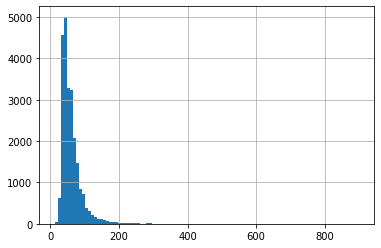

In [28]:
data['total_area'].hist(bins=100)

In [29]:
data.query('total_area > 400').sort_values('total_area', ascending=False)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,locality_name_corrected,one_m2_price,week_day,exposition_month,exposition_year,floor_type,cityCenters_nearest_km
19540,8,420000000.0,900.00,2017-12-06,12,2.80,25.0,409.7,25,NaN,...,2.0,318.0,106.0,Санкт-Петербург,466666.67,2,12,2017,последний,8.0
12859,20,140000000.0,631.20,2019-04-09,7,3.90,4.0,322.3,4,NaN,...,2.0,210.0,NaN,Санкт-Петербург,221799.75,1,4,2019,последний,5.0
3117,19,140000000.0,631.00,2019-03-30,7,NaN,5.0,NaN,5,NaN,...,2.0,210.0,NaN,Санкт-Петербург,221870.05,5,3,2019,последний,5.0
15651,20,300000000.0,618.00,2017-12-18,7,3.40,7.0,258.0,5,NaN,...,2.0,198.0,111.0,Санкт-Петербург,485436.89,0,12,2017,другой,5.0
5358,20,65000000.0,590.00,2019-02-14,15,3.50,6.0,409.0,3,NaN,...,0.0,NaN,14.0,Санкт-Петербург,110169.49,3,2,2019,другой,5.0
4237,1,50000000.0,517.00,2017-10-14,7,NaN,4.0,332.0,3,NaN,...,2.0,540.0,NaN,Санкт-Петербург,96711.80,5,10,2017,другой,2.0
8018,20,84000000.0,507.00,2015-12-17,5,4.45,7.0,301.5,7,True,...,0.0,NaN,1078.0,Санкт-Петербург,165680.47,3,12,2015,последний,6.0
5893,3,230000000.0,500.00,2017-05-31,6,NaN,7.0,NaN,7,NaN,...,2.0,198.0,50.0,Санкт-Петербург,460000.00,2,5,2017,последний,5.0
15016,8,150000000.0,500.00,2016-01-13,4,3.20,7.0,NaN,7,NaN,...,3.0,531.0,303.0,Санкт-Петербург,300000.00,2,1,2016,последний,6.0
12401,20,91500000.0,495.00,2017-06-19,7,4.65,7.0,347.5,7,NaN,...,0.0,NaN,14.0,Санкт-Петербург,184848.48,0,6,2017,последний,6.0


array([[<AxesSubplot:title={'center':'total_area'}>]], dtype=object)

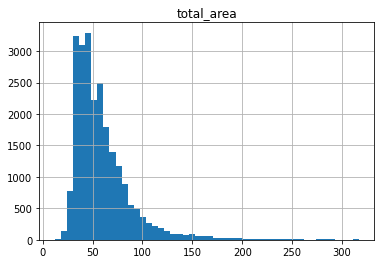

In [30]:
data.query('total_area < 320').hist('total_area', bins=50)

**Наблюдения:** параметр *total_area* в целом имеет нормальное распределение. Есть выбивающиеся значения площади, но судя по остальным данным это не является ошибкой - квартиры с большой площадью находятся в самом городе Санкт-Петербург, имеют либо большое количество комнат, либо большую стоимость, жилая площадь у них в основном больше половины.Если ошибки в значениях и есть, то на результаты анализа они сильно не повлияют.

#### Параметр жилая площадь

In [31]:
print(data['living_area'].describe())

count    21752.000000
mean        34.448356
std         22.037664
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64


<AxesSubplot:>

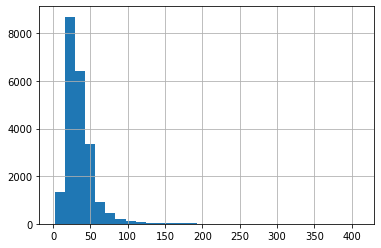

In [32]:
data['living_area'].hist(bins=30)

array([[<AxesSubplot:title={'center':'living_area'}>]], dtype=object)

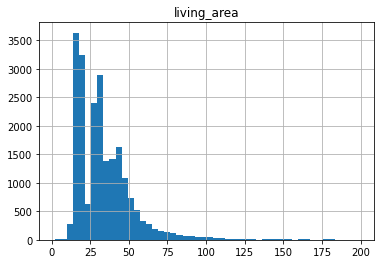

In [33]:
data.query('living_area < 200').hist('living_area', bins=50)

**Наблюдения:** параметр *living_area* повторяет распределение *total_area*. Тоже есть выбивающиеся значения. Т.к. жилая площадь - это часть общей площади, значения выглядят вполне нормально.

#### Параметр площадь кухни

In [34]:
print(data['kitchen_area'].describe())

count    21381.000000
mean        10.566403
std          5.901753
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64


<AxesSubplot:>

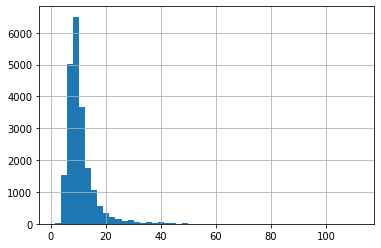

In [35]:
data['kitchen_area'].hist(bins=50)

**Наблюдения:** Распределение параметра *kitchen_area* выглядит нормальным. Наличие малого количества больших значений (максимальное 112) объясняется наличием квартир с большой площадью (кухня 112 м2 у квартиры в 900 м2)

#### Параметр цена объекта

In [36]:
print(data['last_price'].describe())

count    2.365000e+04
mean     6.541127e+06
std      1.089640e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.650000e+06
75%      6.799000e+06
max      7.630000e+08
Name: last_price, dtype: float64


<AxesSubplot:>

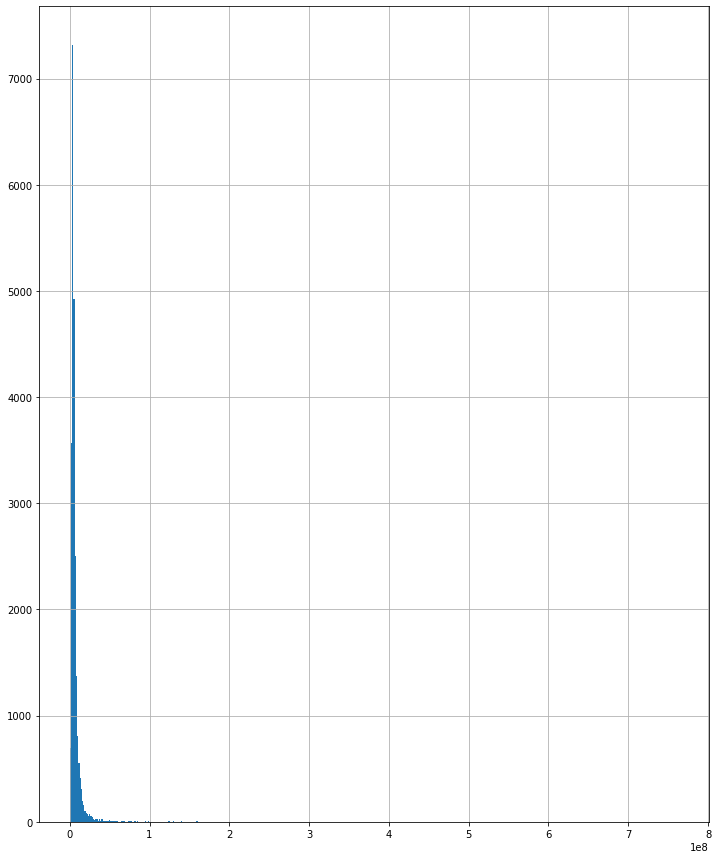

In [37]:
data['last_price'].hist(bins=500, figsize=(12,15))

array([[<AxesSubplot:title={'center':'last_price'}>]], dtype=object)

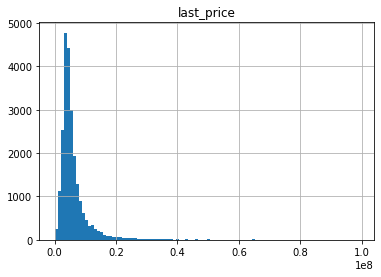

In [38]:
data.query('last_price < 1.0e+8').hist('last_price', bins=100)

In [39]:
data[data['last_price'] > 1.0e+8]['last_price'].value_counts()

130000000.0    3
140000000.0    3
135000000.0    2
150000000.0    2
130278280.0    1
245000000.0    1
155000000.0    1
118000000.0    1
159984000.0    1
289238400.0    1
124480000.0    1
401300000.0    1
124000000.0    1
131000000.0    1
148000000.0    1
120000000.0    1
300000000.0    1
115490000.0    1
119000000.0    1
124350000.0    1
420000000.0    1
180000000.0    1
763000000.0    1
230000000.0    1
125000000.0    1
160000000.0    1
330000000.0    1
122000000.0    1
190870000.0    1
159000000.0    1
240000000.0    1
Name: last_price, dtype: int64

**Наблюдения:** Распределение цен нормальное, но существует очень большой разброс, что является логчным, т.к. это общая картина по ценам очень разных ценовых категорий.

#### Параметр количество комнат

In [40]:
print(data['rooms'].describe())

count    23650.000000
mean         2.070106
std          1.078620
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64


In [41]:
len(data['rooms'].unique())

17

<AxesSubplot:>

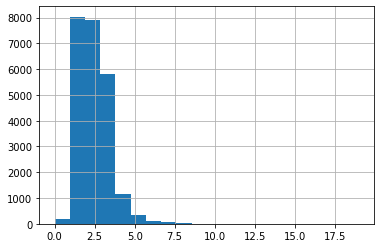

In [42]:
data['rooms'].hist(bins=20)

In [43]:
data.loc[data['rooms'] == 0, ['studio', 'open_plan']]

,studio,open_plan
144,True,False
349,False,True
440,True,False
508,False,True
608,True,False
...,...,...
23210,True,False
23442,False,True
23554,True,False
23592,False,True


In [44]:
data[(data['rooms'] == 0) & (data['studio'] == False) & (data['open_plan'] == False)]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,locality_name_corrected,one_m2_price,week_day,exposition_month,exposition_year,floor_type,cityCenters_nearest_km


In [45]:
data[(data['rooms'] == 0) & ((data['studio'] == True) | (data['open_plan'] == True))]['rooms'].count()

197

In [46]:
data[data['rooms'] > 10]['rooms'].value_counts()

11    2
14    2
16    1
19    1
12    1
15    1
Name: rooms, dtype: int64

array([[<AxesSubplot:title={'center':'rooms'}>]], dtype=object)

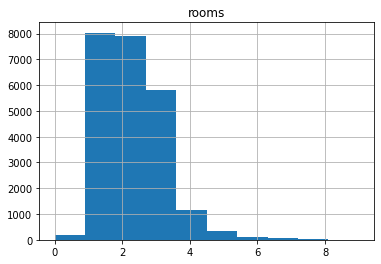

In [47]:
data.query('rooms < 10').hist('rooms', bins=10)

**Наблюдения:** Параметр *rooms* имеет нормальное распределение. Количество комнат = 0 ставится у квартир либо со свободной планировкой, либо у студий.

#### Параметр высота потолков

In [48]:
print(data['ceiling_height'].describe())

count    14490.000000
mean         2.771287
std          1.261593
min          1.000000
25%          2.520000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64


<AxesSubplot:>

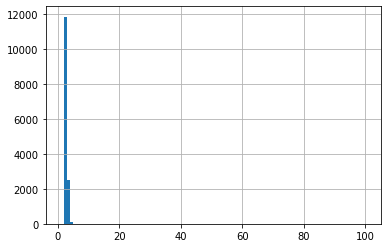

In [49]:
data['ceiling_height'].hist(bins=100)

In [50]:
data[data['ceiling_height'] > 9]['ceiling_height'].value_counts()

27.0     8
25.0     7
32.0     2
14.0     1
20.0     1
24.0     1
27.5     1
10.3     1
22.6     1
26.0     1
100.0    1
Name: ceiling_height, dtype: int64

array([[<AxesSubplot:title={'center':'ceiling_height'}>]], dtype=object)

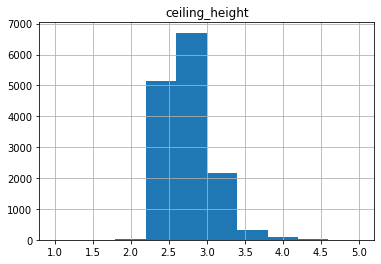

In [51]:
data.hist('ceiling_height', bins=10, range=(1, 5))

**Наблюдения:** Параметр *ceiling_height* имеет нормальное распределение, но в данных есть ошибочные значения. Высота больше 20 метров явно указана неверно. Таких значений мало - 23 от общего числа (меньше 1%)

In [52]:
data['ceiling_height'].unique()

array([  2.7 ,    nan,   3.03,   2.5 ,   2.67,   2.56,   3.05,   2.75,
         2.6 ,   2.9 ,   2.8 ,   2.55,   3.  ,   2.65,   3.2 ,   2.61,
         3.25,   3.45,   2.77,   2.85,   2.64,   2.57,   4.15,   3.5 ,
         3.3 ,   2.71,   4.  ,   2.47,   2.73,   2.84,   3.1 ,   2.34,
         3.4 ,   3.06,   2.72,   2.54,   2.51,   2.78,   2.76,  25.  ,
         2.58,   3.7 ,   2.52,   5.2 ,   2.87,   2.66,   2.59,   2.  ,
         2.45,   3.6 ,   2.92,   3.11,   3.13,   3.8 ,   3.15,   3.55,
         3.16,   3.62,   3.12,   2.53,   2.74,   2.96,   2.46,   5.3 ,
         5.  ,   2.79,   2.95,   4.06,   2.94,   3.82,   3.54,   3.53,
         2.83,   4.7 ,   2.4 ,   3.38,   3.01,   5.6 ,   3.65,   3.9 ,
         3.18,   3.35,   2.3 ,   3.57,   2.48,   2.62,   2.82,   3.98,
         2.63,   3.83,   3.52,   3.95,   3.75,   2.88,   3.67,   3.87,
         3.66,   3.85,   3.86,   4.19,   3.24,   4.8 ,   4.5 ,   4.2 ,
         3.36,  32.  ,   3.08,   3.68,   3.07,   3.37,   3.09,   8.  ,
      

Разбор аномалий в значениях высоты потоков:

In [53]:
data[data['ceiling_height'] >= 20]['ceiling_height']

355       25.0
3148      32.0
4643      25.0
4876      27.0
5076      24.0
5246      27.0
5669      26.0
5807      27.0
6246      25.0
9379      25.0
10773     27.0
11285     25.0
14382     25.0
17496     20.0
17857     27.0
18545     25.0
20478     27.0
20507     22.6
21377     27.5
21824     27.0
22336     32.0
22869    100.0
22938     27.0
Name: ceiling_height, dtype: float64

Для значений высоты потолков больше или равно 20 выполню деление на 10, т.к. скорее всего была ошибка записи данных и вместо дробного числа в данных осталось целое:

In [54]:
def divide_by_10(value):
    if value >= 20:
        value /= 10
        return value
    return value

In [55]:
data['ceiling_height'] = data['ceiling_height'].apply(divide_by_10)
data['ceiling_height'].unique()

array([ 2.7 ,   nan,  3.03,  2.5 ,  2.67,  2.56,  3.05,  2.75,  2.6 ,
        2.9 ,  2.8 ,  2.55,  3.  ,  2.65,  3.2 ,  2.61,  3.25,  3.45,
        2.77,  2.85,  2.64,  2.57,  4.15,  3.5 ,  3.3 ,  2.71,  4.  ,
        2.47,  2.73,  2.84,  3.1 ,  2.34,  3.4 ,  3.06,  2.72,  2.54,
        2.51,  2.78,  2.76,  2.58,  3.7 ,  2.52,  5.2 ,  2.87,  2.66,
        2.59,  2.  ,  2.45,  3.6 ,  2.92,  3.11,  3.13,  3.8 ,  3.15,
        3.55,  3.16,  3.62,  3.12,  2.53,  2.74,  2.96,  2.46,  5.3 ,
        5.  ,  2.79,  2.95,  4.06,  2.94,  3.82,  3.54,  3.53,  2.83,
        4.7 ,  2.4 ,  3.38,  3.01,  5.6 ,  3.65,  3.9 ,  3.18,  3.35,
        2.3 ,  3.57,  2.48,  2.62,  2.82,  3.98,  2.63,  3.83,  3.52,
        3.95,  3.75,  2.88,  3.67,  3.87,  3.66,  3.85,  3.86,  4.19,
        3.24,  4.8 ,  4.5 ,  4.2 ,  3.36,  3.08,  3.68,  3.07,  3.37,
        3.09,  8.  ,  3.26,  3.34,  2.81,  3.44,  2.97,  3.14,  4.37,
        2.68,  3.22,  3.27,  4.1 ,  2.93,  3.46,  3.47,  3.33,  3.63,
        3.32,  1.2 ,

#### Параметр тип этажа квартиры («первый», «последний», «другой»)

In [56]:
print(data['floor_type'].value_counts())

другой       17408
последний     3330
первый        2912
Name: floor_type, dtype: int64


<AxesSubplot:>

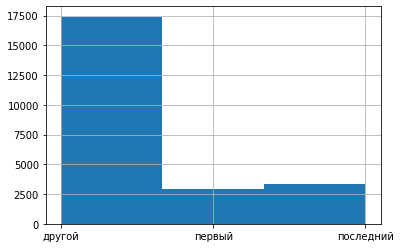

In [57]:
data['floor_type'].hist(bins=3)

**Наблюдения:** В основном в объявлениях встречаются не первые и не последние этажи, что вполне логично.

#### Параметр общее количество этажей в доме

In [58]:
print(data['floors_total'].describe())

count    23565.000000
mean        10.675875
std          6.594823
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64


<AxesSubplot:>

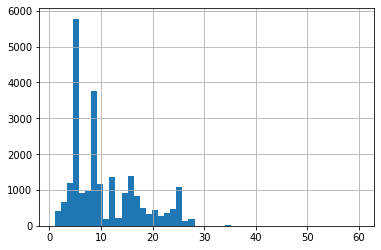

In [59]:
data['floors_total'].hist(bins=50)

In [60]:
data[data['floors_total'] > 35]['floors_total'].value_counts()

36.0    3
37.0    1
60.0    1
52.0    1
Name: floors_total, dtype: int64

<AxesSubplot:>

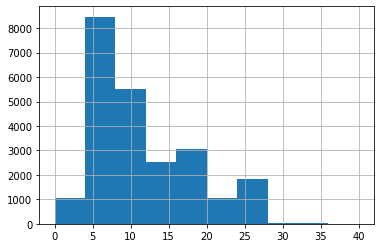

In [61]:
data['floors_total'].hist(range=(0, 40))

In [62]:
data.loc[data['floors_total'] > 40, ['floors_total', 'locality_name', 'last_price']]

,floors_total,locality_name,last_price
2253,60.0,Кронштадт,3800000.0
16731,52.0,Санкт-Петербург,3978000.0


**Наблюдения:** Учитывая среднестатистические застройки в России общее количество этажей в данных выглядит вполне логичным. Есть два запредельных значения - 52 и 60 этажей - Видимо ошибочные, т.к. судя по данным из интернета в Санкт-Петербурге самая высокая многоэтажка имеет 35 этажей.

#### Параметр расстояние до центра города в метрах

In [63]:
print(data['cityCenters_nearest'].describe())

count    18139.000000
mean     14197.860742
std       8606.830295
min        181.000000
25%       9241.000000
50%      13105.000000
75%      16293.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64


<AxesSubplot:>

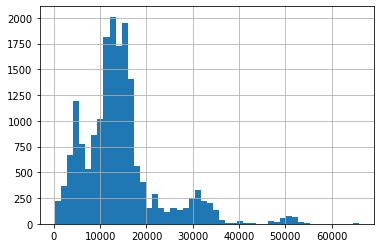

In [64]:
data['cityCenters_nearest'].hist(bins=50)

**Наблюдения:** Расстояния до центра сильно колеблются, т.к. гистограмма отображает картину по разным (разноудалённым) населённый пунктам

#### Параметр расстояние до ближайшего парка

In [65]:
print(data['parks_nearest'].describe())

count    8064.000000
mean      490.830729
std       342.554386
min         1.000000
25%       288.000000
50%       454.500000
75%       612.000000
max      3190.000000
Name: parks_nearest, dtype: float64


<AxesSubplot:>

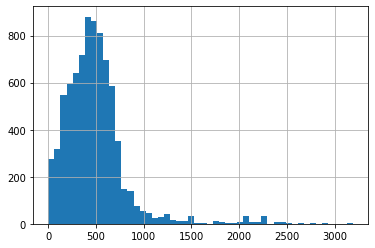

In [66]:
data['parks_nearest'].hist(bins=50)

**Наблюдения:** Параметр *parks_nearest* имеет нормальное распределение

Выборка из общего набора данных для дальнейшего анализа (с исключением аномалий):

In [67]:
data_main_set = data.query('total_area < 900 and (ceiling_height < 20 or ceiling_height.isna()) and floors_total < 40')
data_main_set.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23562 entries, 0 to 23698
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   total_images             23562 non-null  int64         
 1   last_price               23562 non-null  float64       
 2   total_area               23562 non-null  float64       
 3   first_day_exposition     23562 non-null  datetime64[ns]
 4   rooms                    23562 non-null  int64         
 5   ceiling_height           14478 non-null  float64       
 6   floors_total             23562 non-null  float64       
 7   living_area              21697 non-null  float64       
 8   floor                    23562 non-null  int64         
 9   is_apartment             2760 non-null   object        
 10  studio                   23562 non-null  bool          
 11  open_plan                23562 non-null  bool          
 12  kitchen_area             21340 n

### Как быстро продавались квартиры (столбец days_exposition)

In [68]:
print(data['days_exposition'].describe())

count    20470.000000
mean       180.753200
std        219.777916
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64


Среднее (mean) и медиана (50%) отличаются в 2 раза.

<AxesSubplot:>

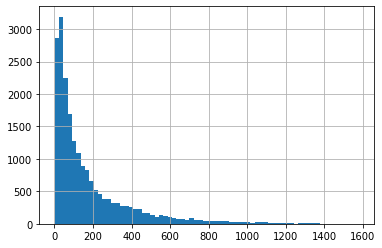

In [69]:
data['days_exposition'].hist(bins=70)

Продажа обычно занимает около 95 дней. Самая быстрая продажа была выполнена за 1 день. К быстрым продажам можно относить продажи до 45 дней, а к медленным больше 231. Запредельно долгими можно считать сделки более 800 дней.

### Определение факторов, которые больше всего влияют на общую (полную) стоимость объекта

    Зависит ли цена от:
        ◦ общей площади;
        ◦ жилой площади;
        ◦ площади кухни;
        ◦ количества комнат;
        ◦ этажа, на котором расположена квартира (первый, последний, другой);
        ◦ даты размещения (день недели, месяц, год)

In [70]:
print('Коэффициент корреляции для общей площади:')
print(data_main_set['last_price'].corr(data_main_set['total_area']))
print('Коэффициент корреляции для жилой площади:')
print(data_main_set['last_price'].corr(data_main_set['living_area']))
print('Коэффициент корреляции для площади кухни:')
print(data_main_set['last_price'].corr(data_main_set['kitchen_area']))

Коэффициент корреляции для общей площади:
0.6430260545754356
Коэффициент корреляции для жилой площади:
0.559113005249558
Коэффициент корреляции для площади кухни:
0.511657924740585


In [71]:
pivot_area = data_main_set.pivot_table(index='locality_name_corrected', 
                                             values=['last_price', 'total_area', 'living_area', 'kitchen_area'], 
                                             aggfunc='median')
pivot_area

,kitchen_area,last_price,living_area,total_area
locality_name_corrected,,,,
Бокситогорск,6.00,785000.0,29.50,44.50
Волосово,8.30,1800000.0,29.80,49.55
Волхов,6.80,1600000.0,30.30,48.00
Всеволожск,10.00,3450000.0,30.00,53.55
Выборг,8.00,2897000.0,30.00,50.20
...,...,...,...,...
село Путилово,7.85,2025000.0,29.30,50.80
село Рождествено,8.15,1800000.0,29.70,54.20
село Русско-Высоцкое,10.70,2400000.0,24.35,48.00


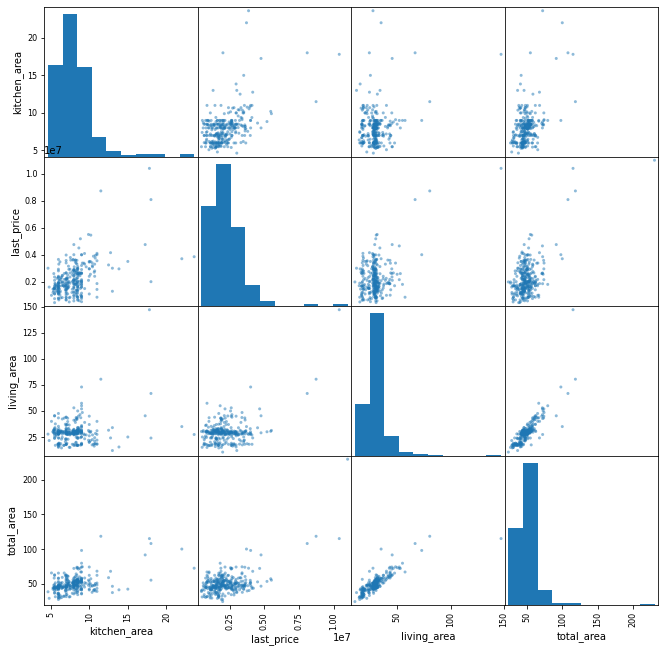

In [72]:
pd.plotting.scatter_matrix(pivot_area, figsize=(11, 11))
plt.show();

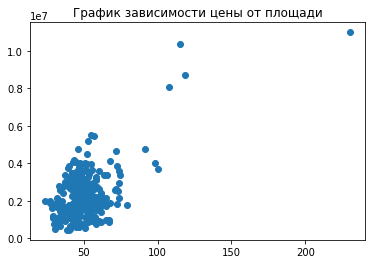

In [73]:
plt.scatter(pivot_area['total_area'], pivot_area['last_price'], marker = 'o')

plt.title('График зависимости цены от площади')
plt.show()

Сильная зависимость цены от площади не прослеживается (в строке графиков last_price нет направленности точек, показывающей зависимость от total_area, living_area, kitchen_area. Есть небольшой уход на возрастание для общей площади.

In [74]:
pivot_rooms = data_main_set.pivot_table(index='rooms', 
                                             values='last_price', 
                                             aggfunc='median')
pivot_rooms

,last_price
rooms,
0,2700000.0
1,3600000.0
2,4768857.0
3,6200000.0
4,9000000.0
5,14000000.0
6,19000000.0
7,24900000.0
8,23095000.0


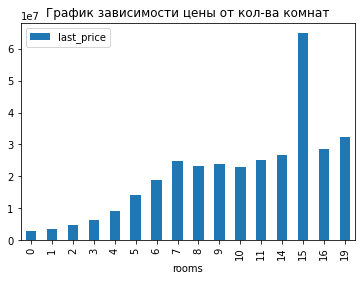

In [75]:
pivot_rooms.plot(kind='bar')
plt.title('График зависимости цены от кол-ва комнат')
plt.show();

In [76]:
pivot_floor_type = data_main_set.pivot_table(index='floor_type',
                                             values='last_price',
                                             aggfunc='median')
pivot_floor_type

,last_price
floor_type,
другой,4850000.0
первый,3900000.0
последний,4300000.0


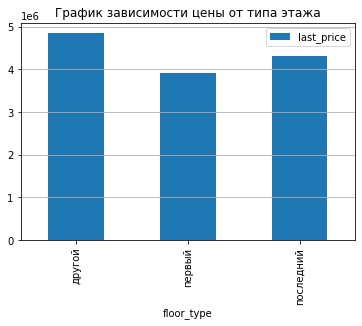

In [77]:
pivot_floor_type.plot(kind='bar')
plt.title('График зависимости цены от типа этажа')
plt.grid(axis='y')
plt.show();

Прослеживается снижение цены для первых этажей.

In [78]:
pivot_week_day_spb = (data_main_set
                  .query('locality_name_corrected == "Санкт-Петербург"')
                  .pivot_table(index='week_day',
                               values='last_price',
                               aggfunc='median')
                 )
pivot_week_day_spb

,last_price
week_day,
0,5512500.0
1,5500000.0
2,5500000.0
3,5685000.0
4,5500000.0
5,5500000.0
6,5400000.0


In [79]:
pivot_week_day_other = (data_main_set
                        .query('locality_name_corrected != "Санкт-Петербург"')
                        .pivot_table(index='week_day',
                                     values='last_price',
                                     aggfunc='median')
                 )
pivot_week_day_other

,last_price
week_day,
0,3300000.0
1,3150000.0
2,3200000.0
3,3100000.0
4,3225000.0
5,2999999.5
6,3194500.0


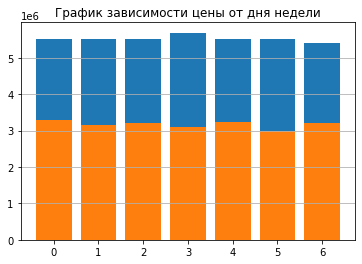

In [80]:
plt.bar(pivot_week_day_spb.index, pivot_week_day_spb.last_price)
plt.bar(pivot_week_day_other.index, pivot_week_day_other.last_price)
plt.title('График зависимости цены от дня недели')
plt.grid(axis='y')
plt.show()

In [81]:
pivot_month_spb = (data_main_set
                  .query('locality_name_corrected == "Санкт-Петербург"')
                  .pivot_table(index='exposition_month',
                               values='last_price',
                               aggfunc='median')
                 )
pivot_month_spb

,last_price
exposition_month,
1,5700000.0
2,5500000.0
3,5600000.0
4,5580000.0
5,5500000.0
6,5325000.0
7,5400000.0
8,5500000.0
9,5626387.0


In [82]:
pivot_month_other = (data_main_set
                     .query('locality_name_corrected != "Санкт-Петербург"')
                     .pivot_table(index='exposition_month', values='last_price', aggfunc='median')
                 )
pivot_month_other

,last_price
exposition_month,
1,3250000.0
2,3100000.0
3,3150000.0
4,3170000.0
5,3200000.0
6,3100000.0
7,3110000.0
8,3194500.0
9,3150000.0


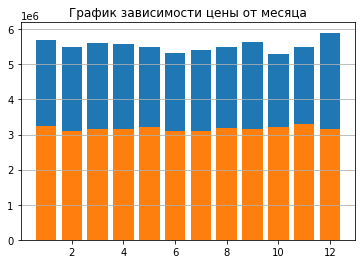

In [83]:
plt.bar(pivot_month_spb.index, pivot_month_spb.last_price)
plt.bar(pivot_month_other.index, pivot_month_other.last_price)
plt.title('График зависимости цены от месяца')
plt.grid(axis='y')
plt.show()

In [84]:
pivot_year_spb = (data_main_set
                  .query('locality_name_corrected == "Санкт-Петербург"')
                  .pivot_table(index='exposition_year',
                               values='last_price',
                               aggfunc='median')
                 )
pivot_year_spb

,last_price
exposition_year,
2014,10600000.0
2015,6200000.0
2016,5450000.0
2017,5300000.0
2018,5490000.0
2019,5900000.0


In [85]:
pivot_year_other = (data_main_set
                  .query('locality_name_corrected != "Санкт-Петербург"')
                  .pivot_table(index='exposition_year',
                               values='last_price',
                               aggfunc='median')
                 )
pivot_year_other

,last_price
exposition_year,
2014,3500100.0
2015,3400000.0
2016,3200000.0
2017,3149000.0
2018,3150000.0
2019,3200000.0


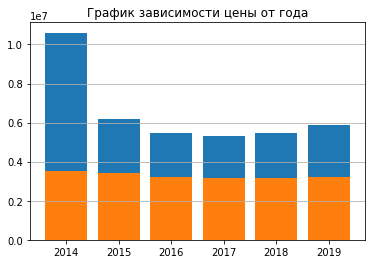

In [86]:
plt.bar(pivot_year_spb.index, pivot_year_spb.last_price)
plt.bar(pivot_year_other.index, pivot_year_other.last_price)
plt.title('График зависимости цены от года')
plt.grid(axis='y')
plt.show()

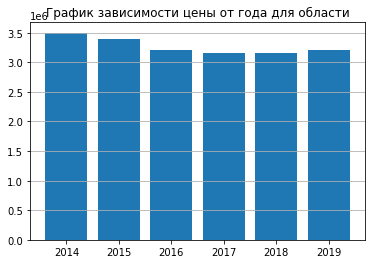

In [87]:
plt.bar(pivot_year_other.index, pivot_year_other.last_price)
plt.title('График зависимости цены от года для области')
plt.grid(axis='y')
plt.show()

По дню и месяцу не видно зависимости. По году наблюдается снижение уровня цен с 2014 к 2017 году и последующее небольшое увеличение уровня цен к 2019 году.

### Расчёт средней цены 1 квадратного метра

Необходимо посчитать среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — построить сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов. Выделить населённые пункты с самой высокой и низкой стоимостью квадратного метра.

Таблица с количеством объявлений и средней ценой квадратного метра для 10 населённых пунктов с наибольшим числом объявлений:

In [88]:
(data
 .groupby('locality_name_corrected').agg(
    count=('locality_name_corrected', 'count'),
    m2_price=('one_m2_price', 'mean')
)
 .sort_values('count', ascending=False)
).head(10)

,count,m2_price
locality_name_corrected,,
Санкт-Петербург,15721,114849.008793
поселок поселок Мурино,556,85681.762572
Кудрово,472,95324.930508
поселок Шушары,440,78677.364318
Всеволожск,398,68654.473970
Пушкин,369,103125.819377
Колпино,338,75424.579112
поселок Парголово,327,90175.913089
Гатчина,307,68746.146515


Населённый пункт с самой низкой стоимостью квадратного метра:

In [89]:
data.loc[data['one_m2_price'] == data['one_m2_price'].min(), ['locality_name', 'one_m2_price']]

,locality_name,one_m2_price
8793,Санкт-Петербург,111.83


Населённый пункт с самой высокой стоимостью квадратного метра:

In [90]:
data.loc[data['one_m2_price'] == data['one_m2_price'].max(), ['locality_name', 'one_m2_price']]

,locality_name,one_m2_price
12971,Санкт-Петербург,1907500.0


### Расчёт средней цены квартир для каждого километра

Ранее было рассчитано расстояние до центра в километрах. Теперь необходимо выделить квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислить среднюю цену каждого километра и выяснить, как стоимость объектов зависит от расстояния до центра города — построить график изменения средней цены для каждого километра от центра Петербурга.

In [91]:
spb_price = (data
             .query('locality_name == "Санкт-Петербург"')
             .groupby('cityCenters_nearest_km')['last_price']
             .mean()
 #.pivot_table(index='cityCenters_nearest_km', values='last_price', aggfunc='mean')
)
spb_price

cityCenters_nearest_km
0.0     3.144912e+07
1.0     2.120672e+07
2.0     1.778832e+07
3.0     1.112658e+07
4.0     1.330428e+07
5.0     1.449912e+07
6.0     1.533842e+07
7.0     1.477515e+07
8.0     9.957717e+06
9.0     6.950659e+06
10.0    6.504119e+06
11.0    6.250815e+06
12.0    5.828545e+06
13.0    6.083141e+06
14.0    5.629101e+06
15.0    5.884751e+06
16.0    5.373131e+06
17.0    5.292395e+06
18.0    5.091331e+06
19.0    5.037675e+06
20.0    5.951465e+06
21.0    5.493469e+06
22.0    5.415524e+06
23.0    4.985376e+06
24.0    3.854430e+06
25.0    4.052840e+06
26.0    3.973013e+06
27.0    8.300000e+06
28.0    5.026429e+06
29.0    4.236667e+06
Name: last_price, dtype: float64

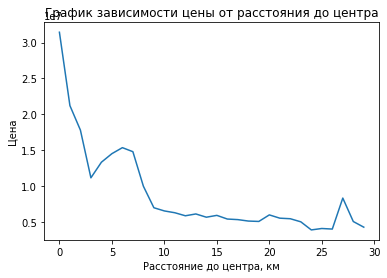

In [92]:
spb_price.plot(x='cityCenters_nearest_km', y='last_price')
plt.title('График зависимости цены от расстояния до центра')
plt.ylabel('Цена')
plt.xlabel('Расстояние до центра, км')
plt.show();

В целом общяя тенденция: чем ближе к центру, тем больше цена

## Общий вывод

В рамках работы над проектом были выполнены следующие действия:<br>
- Для улучшения качества полученных данных
 - были выявлены пропуски, мешающие анализу, и устранены
 - были выявлены аномалии в данных и устранены
 - были найдны и устранены неявные дубликаты в названиях населённых пунктов
- Для анализа были рассчитаны дополнительные параметры, такие, как стоимость одного квадратного метра
- Были определены временные промежудки быстрых и медленных сделок
- Был выполнен анализ влияния значений различных параметров на цену объектов (все параметры предварительно анализировались на предмет корректности и достаточности)

Параметры, влияющие на цену объектов:<br>
* Общая площадь квартиры. По графикам раздела 4.3 заметно небольшой стремление цен вверх при увеличении площади квартиры
* Количество комнат. По графикам раздела 4.3 заметно стремление цен вверх при увеличении количества комнат
* Тип этажа. По графикам раздела 4.3 виден ниже уровень цен для первых этажей
* Населённый пункт. В разделе 4.4 видна разница средних цен в зависимости от населённого пункта расположения квартиры
* Расстояние до центра. В разделе 4.5 на графике видна тенденция снижения цены при удалении от центра. 